In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score)

In [9]:
df=pd.read_csv("RealEstate_HousePrice_Dataset_4200 - RealEstate_HousePrice_Dataset_4200.csv.csv")

# Implement Batch Gradient Descent

Slope (m): 2.02
Intercept (b): 2.92


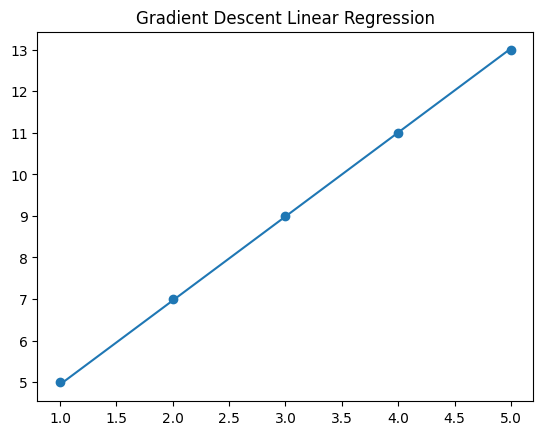

In [10]:
# Sample data
X = np.array([1,2,3,4,5], dtype=float)
y = np.array([5,7,9,11,13], dtype=float)

# Parameters
m = 0
b = 0

learning_rate = 0.01
epochs = 1000

n = len(X)

# Store cost history
costs = []

for i in range(epochs):

    # Predictions
    y_pred = m * X + b

    # Calculate cost
    cost = (1/n) * np.sum((y - y_pred)**2)

    costs.append(cost)

    # Derivatives
    dm = (-2/n) * np.sum(X * (y - y_pred))

    db = (-2/n) * np.sum(y - y_pred)

    # Update parameters
    m = m - learning_rate * dm
    b = b - learning_rate * db

# Final values
print(f"Slope (m): {m:.2f}")
print(f"Intercept (b): {b:.2f}")

# Plot regression line
plt.scatter(X, y)

plt.plot(X, m*X + b)

plt.title("Gradient Descent Linear Regression")

plt.show()

In [31]:
X = df['area_sqft'].values
y = df['house_price_inr'].values

n = len(X)

In [13]:
# Batch Gradient Descent

m = 0
b = 0

lr = 0.01
epochs = 100

batch_costs = []

for epoch in range(epochs):

    y_pred = m * X + b

    # Cost
    cost = (1/n) * np.sum((y - y_pred)**2)
    batch_costs.append(cost)

    # Gradients
    dm = (-2/n) * np.sum(X * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)

    # Update
    m = m - lr * dm
    b = b - lr * db

print("Batch GD")
print("Slope:", round(m,2))
print("Intercept:", round(b,2))

C:\Users\Admin\AppData\Local\Temp\ipykernel_25548\1273462820.py:16: RuntimeWarning: overflow encountered in square
  cost = (1/n) * np.sum((y - y_pred)**2)
C:\Users\Admin\AppData\Local\Temp\ipykernel_25548\1273462820.py:20: RuntimeWarning: overflow encountered in multiply
  dm = (-2/n) * np.sum(X * (y - y_pred))


Batch GD
Slope: nan
Intercept: nan


C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Admin\AppData\Local\Temp\ipykernel_25548\1273462820.py:24: RuntimeWarning: invalid value encountered in scalar subtract
  m = m - lr * dm
C:\Users\Admin\AppData\Local\Temp\ipykernel_25548\1273462820.py:25: RuntimeWarning: invalid value encountered in scalar subtract
  b = b - lr * db


# Stochastic Gradient Desccent

In [33]:
X = df['area_sqft'].values
y = df['house_price_inr'].values

n = len(X)

In [34]:
# Stochastic Gradient Descent

m = 0
b = 0

lr = 0.01
epochs = 100

sgd_costs = []

for epoch in range(epochs):

    for i in range(n):

        xi = X[i]
        yi = y[i]

        y_pred = m * xi + b

        # Gradients
        dm = -2 * xi * (yi - y_pred)
        db = -2 * (yi - y_pred)

        # Update
        m = m - lr * dm
        b = b - lr * db

    # Cost after epoch
    total_pred = m * X + b
    cost = (1/n) * np.sum((y - total_pred)**2)

    sgd_costs.append(cost)

print("\nSGD")
print("Slope:", round(m,2))
print("Intercept:", round(b,2))

C:\Users\Admin\AppData\Local\Temp\ipykernel_25548\3030263075.py:21: RuntimeWarning: overflow encountered in scalar multiply
  dm = -2 * xi * (yi - y_pred)
C:\Users\Admin\AppData\Local\Temp\ipykernel_25548\3030263075.py:25: RuntimeWarning: invalid value encountered in scalar subtract
  m = m - lr * dm



SGD
Slope: nan
Intercept: nan


# Mini-Batch Gradient Descent

In [35]:
X = df['area_sqft'].values
y = df['house_price_inr'].values

n = len(X)

In [36]:
# Mini-Batch Gradient Descent

m = 0
b = 0

lr = 0.01
epochs = 100
batch_size = 3

mini_costs = []

for epoch in range(epochs):

    for i in range(0, n, batch_size):

        X_batch = X[i:i+batch_size]
        y_batch = y[i:i+batch_size]

        batch_n = len(X_batch)

        y_pred = m * X_batch + b

        # Gradients
        dm = (-2/batch_n) * np.sum(X_batch * (y_batch - y_pred))
        db = (-2/batch_n) * np.sum(y_batch - y_pred)

        # Update
        m = m - lr * dm
        b = b - lr * db

    # Cost after epoch
    total_pred = m * X + b
    cost = (1/n) * np.sum((y - total_pred)**2)

    mini_costs.append(cost)

print("\nMini-Batch GD")
print("Slope:", round(m,2))
print("Intercept:", round(b,2))

C:\Users\Admin\AppData\Local\Temp\ipykernel_25548\3329783011.py:24: RuntimeWarning: overflow encountered in multiply
  dm = (-2/batch_n) * np.sum(X_batch * (y_batch - y_pred))
C:\Users\Admin\AppData\Local\Temp\ipykernel_25548\3329783011.py:28: RuntimeWarning: invalid value encountered in scalar subtract
  m = m - lr * dm



Mini-Batch GD
Slope: nan
Intercept: nan


# Compare Convergence Behavior

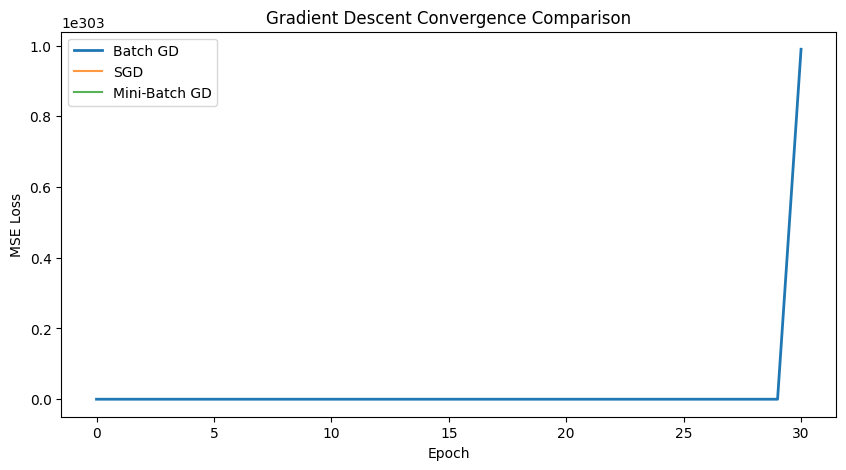

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(batch_costs,
         label='Batch GD',
         linewidth=2)

plt.plot(sgd_costs,
         label='SGD',
         linewidth=1.5,
         alpha=0.8)

plt.plot(mini_costs,
         label='Mini-Batch GD',
         linewidth=1.5,
         alpha=0.8)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.title('Gradient Descent Convergence Comparison')

plt.legend()

plt.show()